# Неделя 1 — EDA

Задание: `docs/week1_eda.md`

## 1. Загрузка данных

In [215]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from src.eda import explore, churn_rate_by


In [216]:
# Клиенты
clients = pd.read_excel('../data/raw/clients.xlsx')

# Помесячное потребление - лежит по месяцам, читаем и склеиваем один раз,
# дальше работаем только с parquet (см. docs/data_dictionary.md)
import glob
usage_files = sorted(glob.glob('../data/raw/usage/*.csv'))
usage = pd.concat([pd.read_csv(f) for f in usage_files], ignore_index=True)

print(clients.shape, usage.shape)

# Проверяем уникальность client_id в clients. Нет ли дубликатов и повторов
print("Уникальных client_id:", clients["client_id"].nunique())
print("Всего строк:", len(clients))
print("Дубликатов client_id:", clients["client_id"].duplicated().sum())

# Проверяем уникальность пары client_id + month в usage
duplicates_usage = usage.duplicated(
    subset=["client_id", "month"]
).sum()

print("Дубликатов client_id + month:", duplicates_usage)

# Проверяем, что все клиенты из usage существуют в clients
clients_ids = set(clients["client_id"])
usage_ids = set(usage["client_id"])

missing_clients = usage_ids - clients_ids

print("Клиентов в usage, которых нет в clients:", len(missing_clients))

print(sorted(usage["month"].unique()))
print("Количество месяцев:", usage["month"].nunique())
print(usage.groupby("month")["client_id"].nunique())


assert clients["client_id"].nunique() == len(clients), "дубликаты client_id в clients"
assert duplicates_usage == 0, "дубликаты client_id+month в usage"
assert len(missing_clients) == 0, "в usage есть клиенты, которых нет в clients"


(50400, 8) (1073079, 7)
Уникальных client_id: 50400
Всего строк: 50400
Дубликатов client_id: 0
Дубликатов client_id + month: 0
Клиентов в usage, которых нет в clients: 0
['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']
Количество месяцев: 30
month
2024-01    27572
2024-02    28433
2024-03    29346
2024-04    30198
2024-05    30904
2024-06    31527
2024-07    32156
2024-08    32818
2024-09    33438
2024-10    34097
2024-11    34635
2024-12    35230
2025-01    35788
2025-02    36344
2025-03    36824
2025-04    37297
2025-05    37758
2025-06    38221
2025-07    38564
2025-08    38889
2025-09    39183
2025-10    39464
2025-11    39709
2025-12    39992
2026-01    40265
2026-02    40448
2026-03    39718
2026-04    

## 2. Чек-лист EDA

Пройдитесь по 7 вопросам из `docs/week1_eda.md` для каждой таблицы.

In [217]:
explore(clients, "Клиенты")
explore(usage, "Помесячное потребление")

===== Клиенты =====
Размер: 50400 строк, 8 столбцов
                     тип  пропусков  пропусков_%  уникальных
client_id         object          0          0.0       50400
segment           object          0          0.0           3
product           object          0          0.0           4
region            object          0          0.0           5
company_name      object          0          0.0       19360
connection_date   object          0          0.0          58
termination_date  object      36361         72.1          27
current_status    object          0          0.0           2
===== Помесячное потребление =====
Размер: 1073079 строк, 7 столбцов
                тип  пропусков  пропусков_%  уникальных
client_id    object          0          0.0       50400
month        object          0          0.0          30
revenue     float64          0          0.0     1016925
traffic_gb  float64          0          0.0       26650
n_tickets     int64          0          0.0       

,тип,пропусков,пропусков_%,уникальных
client_id,object,0,0.0,50400
month,object,0,0.0,30
revenue,float64,0,0.0,1016925
traffic_gb,float64,0,0.0,26650
n_tickets,int64,0,0.0,13
debt,float64,0,0.0,76454
n_sim,int64,0,0.0,348


In [218]:
# Сколько месяцев наблюдается у каждого клиента

months_per_client = (
    usage.groupby("client_id")["month"]
    .nunique()
)

print(months_per_client.describe())
print("Клиентов с 1 месяцем:", (months_per_client == 1).sum())
print("Клиентов с 2 месяцами:", (months_per_client == 2).sum())
print("Клиентов с 3 месяцами:", (months_per_client == 3).sum())
print("Клиентов со всеми 30 месяцами:", (months_per_client == 30).sum())

count    50400.000000
mean        21.291250
std          9.127167
min          3.000000
25%         13.000000
50%         24.000000
75%         30.000000
max         30.000000
Name: month, dtype: float64
Клиентов с 1 месяцем: 0
Клиентов с 2 месяцами: 0
Клиентов с 3 месяцами: 27
Клиентов со всеми 30 месяцами: 19985


In [219]:
# Проверяем последовательность месяцев внутри истории каждого клиента.
# Векторно: без цикла по 50 400 клиентам (sort + groupby + diff)
usage_check = usage.copy()
usage_check["month"] = pd.to_datetime(usage_check["month"])
usage_check = usage_check.sort_values(["client_id", "month"])

gap_days = usage_check.groupby("client_id")["month"].diff().dt.days
n_with_gaps = usage_check.loc[gap_days > 40, "client_id"].nunique()

print("Клиентов с подозрительными дырами:", n_with_gaps)

Клиентов с подозрительными дырами: 0


In [220]:
# Последние 10 месяцев подключений — хвост таблицы
clients["connection_date"].value_counts().sort_index().tail(10)

connection_date
2025-07    912
2025-08    902
2025-09    900
2025-10    872
2025-11    912
2025-12    926
2026-01    934
2026-02    930
2026-03     28
2026-04     27
Name: count, dtype: int64

### Важное наблюдение: приток новых клиентов остановился в марте 2026

С июля 2025 по февраль 2026 компания стабильно подключала по ~900 новых клиентов
в месяц. Начиная с марта 2026 приток резко упал: март — 28, апрель — 27,
май и июнь — 0 новых подключений.

Это значит, что база живых клиентов теперь может расти только если отток будет
меньше 28 клиентов в месяц, а с текущей долей оттока ~30% это невозможно.
Поэтому в данных мы и видим падение общего числа клиентов ближе к концу периода.

Раньше в журнале я просто констатировал факт падения числа клиентов,
но не объяснил причину — а она была прямо в этой таблице.

In [221]:
clients["termination_date"] = pd.to_datetime(
    clients["termination_date"],
    format="%Y-%m",
    errors="coerce"
)

clients["connection_date"] = pd.to_datetime(
    clients["connection_date"],
    format="%Y-%m"
)

print("Самая ранняя дата подключения:",
      clients["connection_date"].min())

print("Самая поздняя дата подключения:",
      clients["connection_date"].max())

print("Самая ранняя дата расторжения:",
      clients["termination_date"].min())

print("Самая поздняя дата расторжения:",
      clients["termination_date"].max())

Самая ранняя дата подключения: 2021-07-01 00:00:00
Самая поздняя дата подключения: 2026-04-01 00:00:00
Самая ранняя дата расторжения: 2024-04-01 00:00:00
Самая поздняя дата расторжения: 2026-06-01 00:00:00


In [222]:
# Сохраняем parquet ПОСЛЕ приведения дат, чтобы в файле лежало то же, что в памяти
clients.to_parquet('../data/processed/clients.parquet')
usage.to_parquet('../data/processed/usage.parquet')

In [223]:
usage_clients = usage["client_id"].nunique()
clients_total = clients["client_id"].nunique()

matched_clients = usage[
    usage["client_id"].isin(clients["client_id"])
]["client_id"].nunique()

print("Всего клиентов в clients:", clients_total)
print("Клиентов в usage:", usage_clients)
print("Сопоставлено:", matched_clients)
print(
    "Доля сопоставленных:",
    round(matched_clients / usage_clients * 100, 2),
    "%"
)

Всего клиентов в clients: 50400
Клиентов в usage: 50400
Сопоставлено: 50400
Доля сопоставленных: 100.0 %


In [224]:
# т.к 100% client_id из usage находятся в clients, то:

In [225]:
LAST_MONTHS = ["2026-04", "2026-05", "2026-06"]
NORM_MONTHS = [
    "2025-04", "2025-05", "2025-06", "2025-07", "2025-08", "2025-09",
    "2025-10", "2025-11", "2025-12", "2026-01", "2026-02", "2026-03"
]

# Метка оттока: три класса вместо одного.
# explicit — договор расторгнут
# silent — тихий отток
# active — платит до конца периода

# Считаем "норму" (средний чек за 12 месяцев до последних 3)
norm_rev = usage[usage["month"].isin(NORM_MONTHS)].groupby("client_id")["revenue"].mean()
recent_rev = usage[usage["month"].isin(LAST_MONTHS)].groupby("client_id")["revenue"].sum()

# Подставляем в справочник клиентов
clients["norm_monthly"] = clients["client_id"].map(norm_rev).fillna(0)
clients["recent_total"] = clients["client_id"].map(recent_rev).fillna(0)

# Безопасно считаем ratio (защищаемся от деления на ноль)
clients["ratio"] = 0.0
mask_has_norm = clients["norm_monthly"] > 0
clients.loc[mask_has_norm, "ratio"] = (
    clients.loc[mask_has_norm, "recent_total"] / (clients.loc[mask_has_norm, "norm_monthly"] * 3)
)

# Собираем итоговую метку churn_type
clients["churn_type"] = "active"
# Явный отток: договор расторгнут
clients.loc[clients["termination_date"].notna(), "churn_type"] = "explicit"
# Тихий отток: договор НЕ расторгнут, но выручка < 20% от нормы
silent_mask = (clients["termination_date"].isna()) & (clients["ratio"] < 0.20)
clients.loc[silent_mask, "churn_type"] = "silent"

print("=== Новая разбивка по типам оттока ===")
print(clients["churn_type"].value_counts())

# Обновляем бинарную метку (явный + тихий = 1, активный = 0)
clients["is_churned"] = (clients["churn_type"] != "active").astype(int)
print(f"\nИтоговая доля оттока (явный + тихий): {clients['is_churned'].mean() * 100:.2f}%")

clients.to_parquet("../data/processed/clients.parquet")

=== Новая разбивка по типам оттока ===
churn_type
active      34815
explicit    14039
silent       1546
Name: count, dtype: int64

Итоговая доля оттока (явный + тихий): 30.92%


Средняя нормализованная выручка по месяцам до ухода
months_to_churn
-6    1.242572
-5    1.231620
-4    1.142306
-3    0.952382
-2    0.557950
-1    0.214742
 0    0.033049
Name: revenue_normed, dtype: float64

Среднее число тикетов по месяцам до ухода
months_to_churn
-6    0.267191
-5    0.333110
-4    0.476398
-3    0.720778
-2    1.085476
-1    1.490348
 0    1.859748
Name: n_tickets, dtype: float64


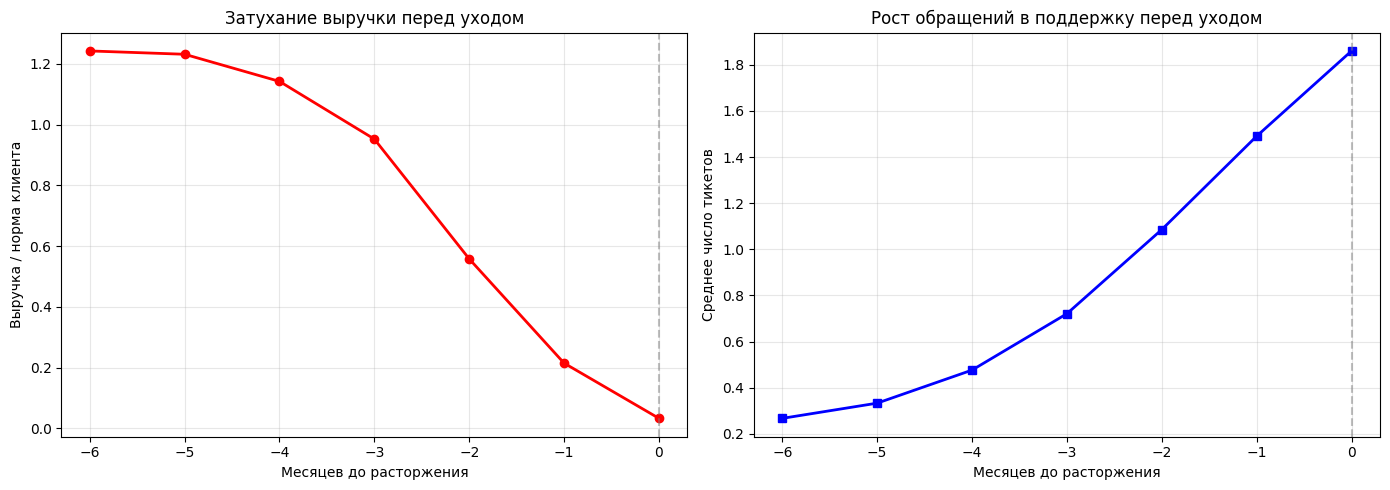

In [226]:
# динамика выручки и тикетов перед уходом

# Берем только явных отточников
churned_clients = clients[clients["churn_type"] == "explicit"].copy()

# Нормализуем месяц расторжения к datetime
churned_clients["termination_dt"] = pd.to_datetime(
    churned_clients["termination_date"], format="%Y-%m", errors="coerce"
)

# Считаем "норму" каждого клиента (средняя выручка за 12 месяцев до месяца расторжения)
def get_norm_for_client(client_id, termination_month):
    """Средняя выручка за 12 месяцев до месяца расторжения."""
    term_date = pd.Timestamp(termination_month)
    start_date = term_date - pd.DateOffset(months=12)

    mask = (
        (usage["client_id"] == client_id)
        & (pd.to_datetime(usage["month"]) >= start_date)
        & (pd.to_datetime(usage["month"]) < term_date)
    )
    return usage.loc[mask, "revenue"].mean()

churned_clients["norm_start"] = churned_clients["termination_dt"] - pd.DateOffset(months=12)

# Merge с usage для получения данных в окне нормы
usage_dt = usage.copy()
usage_dt["month_dt"] = pd.to_datetime(usage_dt["month"])

norm_data = usage_dt.merge(
    churned_clients[["client_id", "norm_start", "termination_dt"]],
    on="client_id",
    how="inner"
)
norm_data = norm_data[
    (norm_data["month_dt"] >= norm_data["norm_start"])
    & (norm_data["month_dt"] < norm_data["termination_dt"])
]

# Средняя выручка за месяц в период нормы для каждого клиента
client_norm = norm_data.groupby("client_id")["revenue"].mean().reset_index()
client_norm.columns = ["client_id", "norm_revenue"]

# Теперь берем данные за 6 месяцев до расторжения и сам месяц расторжения
churned_clients["window_start"] = churned_clients["termination_dt"] - pd.DateOffset(months=6)

window_data = usage_dt.merge(
    churned_clients[["client_id", "window_start", "termination_dt"]],
    on="client_id",
    how="inner"
)
window_data = window_data[
    (window_data["month_dt"] >= window_data["window_start"])
    & (window_data["month_dt"] <= window_data["termination_dt"])
]

# Считаем "месяцев до расторжения" (0 = месяц расторжения, -1 = за месяц до, и т.д.)
window_data["months_to_churn"] = (
    (window_data["month_dt"] - window_data["termination_dt"]).dt.days / 30.44
).round().astype(int)

# Подставляем норму и нормализуем выручку
window_data = window_data.merge(client_norm, on="client_id", how="left")
window_data["revenue_normed"] = window_data["revenue"] / window_data["norm_revenue"]
window_data["revenue_normed"] = window_data["revenue_normed"].fillna(0)

# Усредняем по всем клиентам для каждого месяца до ухода
avg_revenue = window_data.groupby("months_to_churn")["revenue_normed"].mean()
avg_tickets = window_data.groupby("months_to_churn")["n_tickets"].mean()

print("Средняя нормализованная выручка по месяцам до ухода")
print(avg_revenue.sort_index())
print("\nСреднее число тикетов по месяцам до ухода")
print(avg_tickets.sort_index())

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: выручка
ax1.plot(avg_revenue.index, avg_revenue.values, marker='o', linewidth=2, color='red')
ax1.set_xlabel('Месяцев до расторжения')
ax1.set_ylabel('Выручка / норма клиента')
ax1.set_title('Затухание выручки перед уходом')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.grid(alpha=0.3)

# График 2: тикеты
ax2.plot(avg_tickets.index, avg_tickets.values, marker='s', linewidth=2, color='blue')
ax2.set_xlabel('Месяцев до расторжения')
ax2.set_ylabel('Среднее число тикетов')
ax2.set_title('Рост обращений в поддержку перед уходом')
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [227]:
# Берем только нерасторгнутых клиентов
not_terminated = clients[clients["termination_date"].isna()]

# их выручка за 3 месяца
their_rev = not_terminated["client_id"].map(recent_rev).fillna(0)

print("=== Распределение выручки за последние 3 месяца у 'не расторгнутых' ===")
print(their_rev.describe(percentiles=[.5, .75, .9, .95, .99]))

print("\n=== Сколько их имеют подозрительно маленькую выручку: ===")
print(f"  Ровно 0 руб:   {(their_rev == 0).sum()}")
print(f"  Меньше 100 руб:  {(their_rev < 100).sum()}")
print(f"  Меньше 1000 руб: {(their_rev < 1000).sum()}")
print(f"  Меньше 5000 руб: {(their_rev < 5000).sum()}")

=== Распределение выручки за последние 3 месяца у 'не расторгнутых' ===
count    3.636100e+04
mean     6.264494e+05
std      1.280415e+06
min      4.568900e+02
50%      1.176419e+05
75%      4.839949e+05
90%      2.010549e+06
95%      3.195612e+06
99%      6.172244e+06
max      1.789609e+07
Name: client_id, dtype: float64

=== Сколько их имеют подозрительно маленькую выручку: ===
  Ровно 0 руб:   0
  Меньше 100 руб:  0
  Меньше 1000 руб: 42
  Меньше 5000 руб: 2188


In [228]:
# Период "нормы": 12 месяцев до последних 3 месяцев
# Последние 3 месяца: 2026-04, 2026-05, 2026-06
# Норма: 2025-04 ... 2026-03
NORM_MONTHS = [
    "2025-04", "2025-05", "2025-06", "2025-07", "2025-08", "2025-09",
    "2025-10", "2025-11", "2025-12", "2026-01", "2026-02", "2026-03"
]

# Средняя выручка за месяц в период нормы
norm_rev = (
    usage[usage["month"].isin(NORM_MONTHS)]
    .groupby("client_id")["revenue"]
    .mean()
)

not_terminated = clients[clients["termination_date"].isna()].copy()
not_terminated["norm_monthly"] = not_terminated["client_id"].map(norm_rev).fillna(0)
not_terminated["recent_total"] = not_terminated["client_id"].map(recent_rev).fillna(0)
not_terminated["expected_3m"] = not_terminated["norm_monthly"] * 3

# Доля от ожидаемого
not_terminated["ratio"] = not_terminated["recent_total"] / not_terminated["expected_3m"]
not_terminated.loc[not_terminated["expected_3m"] == 0, "ratio"] = 0

print("=== Распределение ratio (последние 3 мес / ожидаемые 3 мес) ===")
print(not_terminated["ratio"].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9]))

print("\n=== Сколько клиентов имеют резкое падение: ===")
print(f"  ratio < 0.10 (упало в 10+ раз): {(not_terminated['ratio'] < 0.10).sum()}")
print(f"  ratio < 0.20 (упало в 5+ раз):  {(not_terminated['ratio'] < 0.20).sum()}")
print(f"  ratio < 0.30 (упало в 3+ раз):  {(not_terminated['ratio'] < 0.30).sum()}")

=== Распределение ratio (последние 3 мес / ожидаемые 3 мес) ===
count    36361.000000
mean         0.965215
std          0.281024
min          0.000000
1%           0.095472
5%           0.236687
10%          0.766631
25%          0.896416
50%          0.992333
75%          1.089110
90%          1.195012
max          2.755657
Name: ratio, dtype: float64

=== Сколько клиентов имеют резкое падение: ===
  ratio < 0.10 (упало в 10+ раз): 411
  ratio < 0.20 (упало в 5+ раз):  1546
  ratio < 0.30 (упало в 3+ раз):  2160


## 3. Доля оттока по сегментам/продуктам/регионам

In [229]:
print("=== Отток по сегментам ===")
print(
    churn_rate_by(
        clients,
        target_col="is_churned",
        group_col="segment"
    )
)

print("\n=== Отток по продуктам ===")
print(
    churn_rate_by(
        clients,
        target_col="is_churned",
        group_col="product"
    )
)

print("\n=== Отток по регионам ===")
print(
    churn_rate_by(
        clients,
        target_col="is_churned",
        group_col="region"
    )
)

=== Отток по сегментам ===
                доля_оттока  клиентов
segment                              
малый бизнес       0.350992     24388
средний бизнес     0.300837     17079
крупный бизнес     0.211239      8933

=== Отток по продуктам ===
                  доля_оттока  клиентов
product                                
облачные сервисы     0.312124     12463
телефония            0.311634     12627
мобильная связь      0.309719     12676
интернет             0.303467     12634

=== Отток по регионам ===
                 доля_оттока  клиентов
region                                
Москва              0.316219      9914
Юг                  0.314894     10105
Урал                0.305864     10096
Сибирь              0.305203     10167
Санкт-Петербург     0.304111     10118


## 4. Динамика ушедших vs оставшихся клиентов

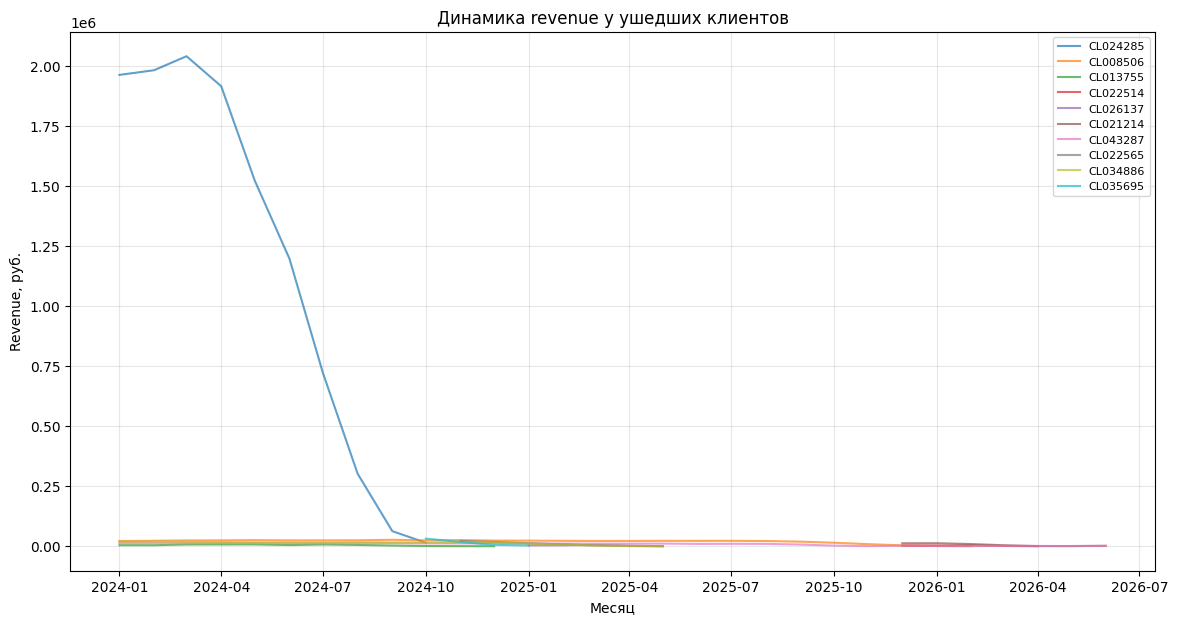

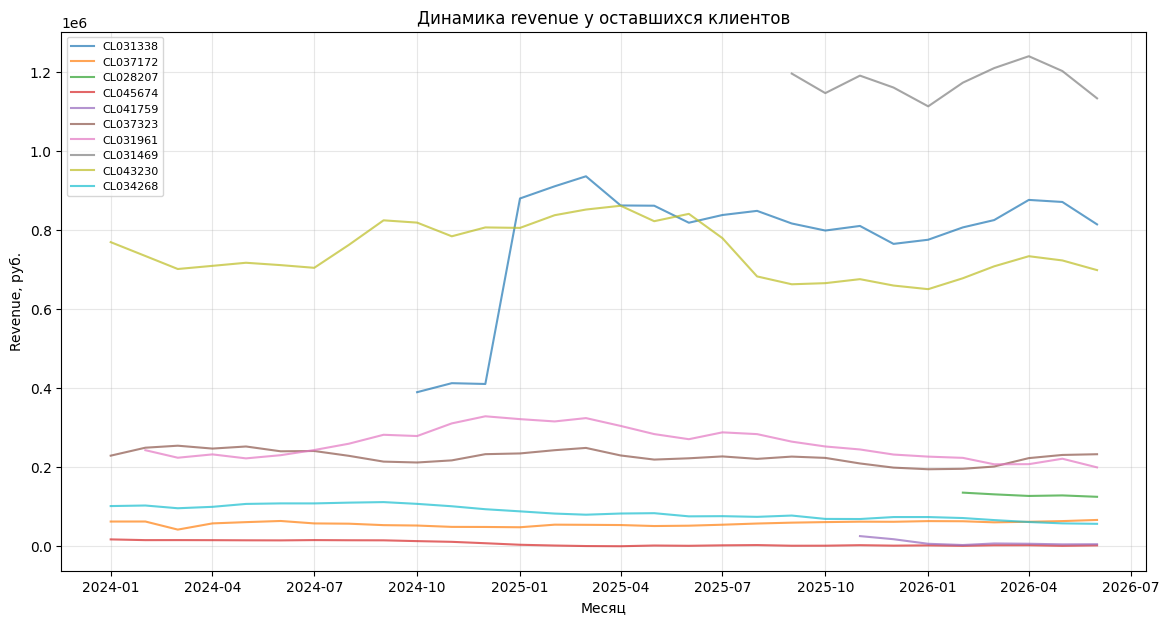

In [230]:
# Добавляем статус клиента к помесячным данным
usage_with_status = usage.merge(
    clients[["client_id", "is_churned"]],
    on="client_id",
    how="left"
)

usage_with_status["month"] = pd.to_datetime(
    usage_with_status["month"]
)

# Выбираем 10 ушедших и 10 оставшихся клиентов
churned_clients = (
    clients.loc[clients["is_churned"] == 1, "client_id"]
    .sample(10, random_state=42)
)

active_clients = (
    clients.loc[clients["is_churned"] == 0, "client_id"]
    .sample(10, random_state=42)
)

plt.figure(figsize=(14, 7))

for client_id in churned_clients:
    client_data = usage_with_status[
        usage_with_status["client_id"] == client_id
    ].sort_values("month")
    
    plt.plot(
        client_data["month"],
        client_data["revenue"],
        alpha=0.7,
        label=client_id
    )

plt.title("Динамика revenue у ушедших клиентов")
plt.xlabel("Месяц")
plt.ylabel("Revenue, руб.")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()



plt.figure(figsize=(14, 7))

for client_id in active_clients:
    client_data = usage_with_status[
        usage_with_status["client_id"] == client_id
    ].sort_values("month")
    
    plt.plot(
        client_data["month"],
        client_data["revenue"],
        alpha=0.7,
        label=client_id
    )

plt.title("Динамика revenue у оставшихся клиентов")
plt.xlabel("Месяц")
plt.ylabel("Revenue, руб.")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()


In [231]:
print("Полных дубликатов в usage:", usage.duplicated().sum())
print("Минимальные значения в usage:")
print(
    usage[["revenue", "traffic_gb", "n_tickets", "debt", "n_sim"]].min()
)

Полных дубликатов в usage: 0
Минимальные значения в usage:
revenue       5.61
traffic_gb    0.00
n_tickets     0.00
debt          0.00
n_sim         0.00
dtype: float64


**отрицательных значений нет из блока выше**

`Важные сведения clients:`

50 400 клиентов

50 400 уникальных client_id

0 дубликатов client_id

0 полных дубликатов


`usage:`

0 дубликатов client_id + month

0 полных дубликатов

100% client_id существуют в clients

30 месяцев наблюдения

In [232]:
# 1. Сбой марта 2025: средние тикеты и трафик по месяцам
monthly = usage.groupby("month").agg(
    tickets_mean=("n_tickets", "mean"),
    traffic_mean=("traffic_gb", "mean"),
).round(2)
print("Средние тикеты и трафик, январь-июнь 2025")
print(monthly.loc["2025-01":"2025-06"])

# 2. Нули в n_sim
zero_sim = usage[usage["n_sim"] == 0]
print("\nНули в n_sim")
print("Строк с n_sim == 0:", len(zero_sim))
print("Из них с revenue > 1000:", (zero_sim["revenue"] > 1000).sum())

usage_full = usage.merge(
    clients[["client_id", "segment", "product"]], on="client_id", how="left"
)
print("\nДоля строк с n_sim == 0 по продуктам:")
print(usage_full.groupby("product")["n_sim"].apply(lambda s: round((s == 0).mean(), 3)))

# 3. Выбросы: медианы выручки по сегментам
print("\nМедианы выручки по сегментам")
print(usage_full.groupby("segment")["revenue"].median().round(0))

# 4. Компании: сколько client_id на одну компанию
print("\nКомпании")
print("Уникальных company_name:", clients["company_name"].nunique())
print("Всего клиентов:", len(clients))
print("Топ-5 компаний по числу client_id:")
print(clients["company_name"].value_counts().head(5))

Средние тикеты и трафик, январь-июнь 2025
         tickets_mean  traffic_mean
month                              
2025-01          0.28        196.32
2025-02          0.27        196.31
2025-03          1.78        136.33
2025-04          0.29        194.50
2025-05          0.29        194.30
2025-06          0.29        193.11

Нули в n_sim
Строк с n_sim == 0: 37417
Из них с revenue > 1000: 21906

Доля строк с n_sim == 0 по продуктам:
product
интернет            0.035
мобильная связь     0.034
облачные сервисы    0.034
телефония           0.036
Name: n_sim, dtype: float64

Медианы выручки по сегментам
segment
крупный бизнес    671314.0
малый бизнес       11668.0
средний бизнес     98247.0
Name: revenue, dtype: float64

Компании
Уникальных company_name: 19360
Всего клиентов: 50400
Топ-5 компаний по числу client_id:
company_name
Прогресс-НЮЛ    41
Партнёр-НЮЛ     40
Атлант-НЮЛ      36
Триумф-НЮЛ      35
Вектор-НЮЛ      34
Name: count, dtype: int64


## Раздел находок (обязательный по словарю данных)

### 1. Сбой марта 2025
В марте 2025 по всей базе резко прыгнули тикеты (с 0.27 до 1.78) и упал трафик
(с 196 до 136). В апреле всё вернулось в норму. Это один месяц, вся база сразу —
похоже на операционный сбой (авария в сети, проблемы с биллингом), а не на
поведение клиентов. На неделе 3 этот месяц отравит любой признак с окном
(например, средний чек за 6 месяцев), поэтому его надо либо исключать, либо
помечать как аномалию.

### 2. Нули в n_sim
В данных 37 417 строк с n_sim = 0, из них 21 906 имеют выручку больше 1000 руб.
Это странно: клиент платит, но SIM-карт у него ноль. Доля нулей одинаковая
по всем продуктам (~3.5%), значит это не связано с типом услуги. Возможно,
это технические нули (когда поле не заполнено), или клиенты, которые платят,
но SIM-карты у них не активны. Нужно разобраться перед построением признаков.

### 3. Выбросы — это не ошибки
Медианы выручки по сегментам: малый бизнес — 12к, средний — 98к, крупный — 671к.
Разброс огромный, но это нормально: у крупного бизнеса и должны быть миллионы.
"Хвост выбросов" на общем графике — это просто крупные клиенты, удалять их нельзя.
Модель должна научиться работать с разными сегментами (или строить отдельные модели
по сегментам, как планируется на неделе 4).

### 4. Группы компаний
19 360 уникальных company_name на 50 400 клиентов. Топ компании имеют 34-41
client_id (например, "Прогресс-НЮЛ" — 41 клиент). Это группы компаний или филиалы.
Гипотеза: если одна компания уходит, то все её филиалы могут уйти синхронно.
Это скрытый паттерн, который можно использовать как признак (например,
"ушёл ли кто-то из моей группы компаний в последние 3 месяца").

## 5. Выводы


1. **Объём и структура данных.**  
   Таблица клиентов содержит 50 400 уникальных клиентов, а таблица помесячного потребления — 1 073 079 записей за 30 месяцев с января 2024 по июнь 2026. Дубликатов по ключам и полных дубликатов не обнаружено. Все клиенты из `usage` присутствуют в таблице `clients`, доля сопоставленных клиентов составляет 100%.

2. **Период наблюдения.**  
   Для клиентов доступно от 3 до 30 месяцев истории, медиана составляет 24 месяца. У 19 985 клиентов есть данные за все 30 месяцев. Подозрительных пропусков месяцев внутри истории клиентов не обнаружено.

3. **Аномалии и выбросы.**  
   Пропусков в числовых признаках `usage` нет, отрицательных значений также не обнаружено. При этом присутствуют сильные выбросы: максимальный `revenue` составляет около 10,78 млн руб., а максимальный `traffic_gb` — около 11 640 ГБ. Эти значения требуют дополнительной проверки на следующих этапах анализа.

4. **Базовый уровень оттока.**  
   На конец периода наблюдения (июнь 2026) доля ушедших клиентов составляет 27,86%: 14 039 клиентов из 50 400. По продуктам и регионам различия относительно небольшие: отток по продуктам находится примерно в диапазоне 27,5–28,0%, по регионам — 27,4–28,6%.

5. **Первая проверка гипотезы о сегментах.**  
   Сегмент показывает существенно более сильную связь с оттоком, чем продукт или регион. Доля оттока составляет 30,88% для малого бизнеса, 27,60% для среднего и 20,11% для крупного бизнеса. Разница между малым и крупным бизнесом составляет 10,77 п.п., поэтому сегмент является перспективным признаком для дальнейшего моделирования и анализа причин оттока. Графики `revenue` также показывают, что у части ушедших клиентов перед расторжением наблюдается заметное снижение или резкое обнуление выручки.